**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 2: Alien Pet Health, Machine Learning*

# Identification

Name: Jamie Bly<br/>
Student Number: 300231604

## 1. Data

Assignment 2 includes two versions of the same dataset: one containing missing values and the other without. The version with missing values was derived from the complete dataset:

- [github.com/turcotte/csi4106-f25/tree/main/assignments-data/a2](https://github.com/turcotte/csi4106-f25/tree/main/assignments-data/a2)

In your notebook, you can access and read the data directly from this GitHub repository.

- [alien_pet_health-realism-clean.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv)
- [alien_pet_health-realism-clean-missing.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean-missing.csv)

## 2. Tasks

The tasks are arranged in a particular sequence to maintain brevity and clarity. There is flexibility in structuring your code. Enhance its organization by adding code cells as needed. You may alter the order of tasks; for example, you might opt to define helper methods initially. Nonetheless, it is crucial that the teaching assistant can effortlessly identify the code segments associated with each task.

(1) **Load the dataset**

- Read the CSV file without missing data (`alien_pet_health-realism-clean.csv`).

- Show the shape of the data, as well as the first five rows.

In [1]:
# Python code
%pip install pandas 
import pandas as pd
import numpy as np

data = pd.read_csv("https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv")
print(data.shape)
print(data.head())
df = pd.DataFrame(data)


Note: you may need to restart the kernel to use updated packages.
(5000, 8)
   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  \
0                -3.5           c2               2             0   
1                10.5           c1               2             0   
2                 9.6           c2               5             0   
3                -4.0           c1               4             0   
4                 0.3           c4               5             1   

   health_outcome  
0               1  
1               0  
2               0  
3               1  
4               1  


(2) **Feature Distribution Analysis**:

- To identify the appropriate encoding method for each feature, it is helpful to examine their distributions using visualization tools such as histograms and box plots. This analysis will enable data-driven decisions on appropriate encoding strategies.

Note: you may need to restart the kernel to use updated packages.


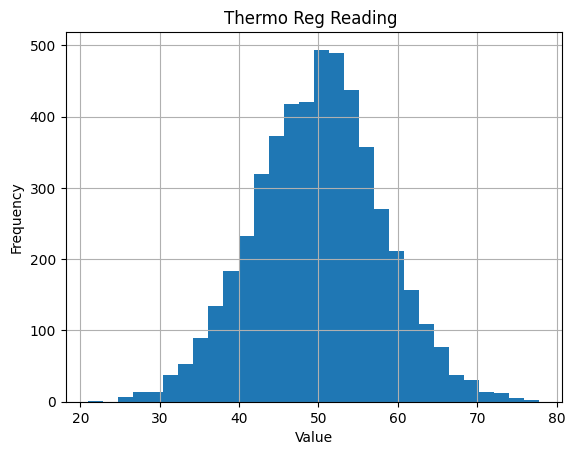

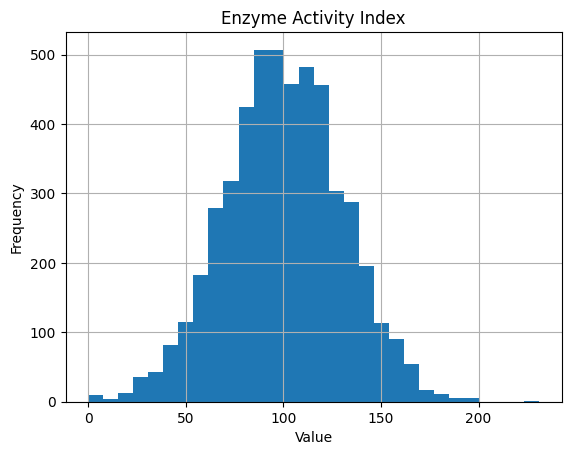

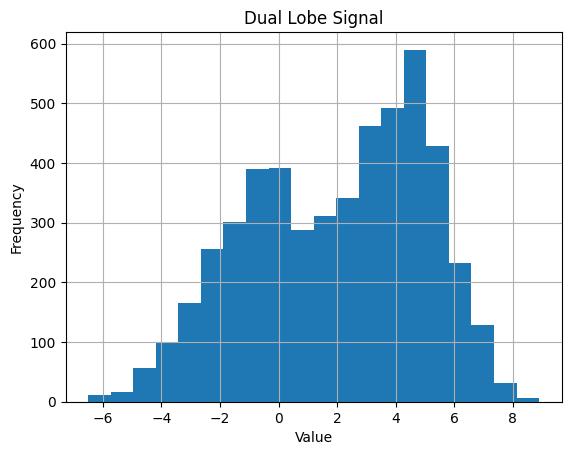

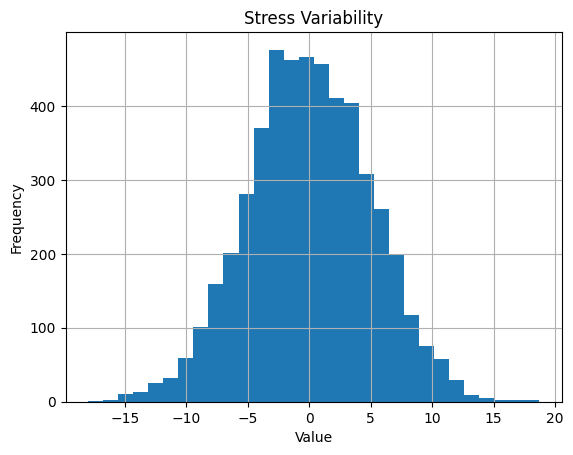

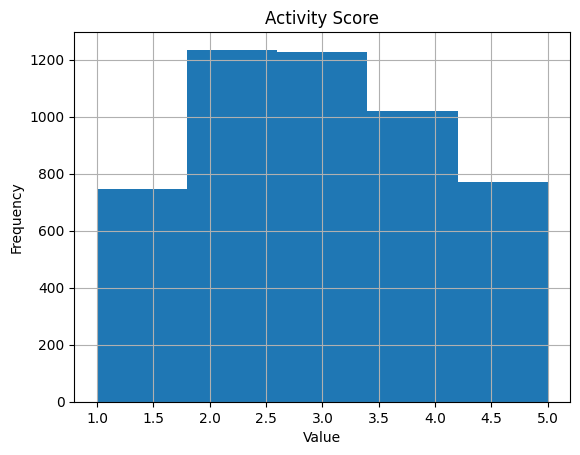

In [2]:
# Python code
%pip install matplotlib
import matplotlib.pyplot as plt

thermoreg_hist = data['thermoreg_reading'].hist(bins=30)
plt.title("Thermo Reg Reading ")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show() 

enzymeActivityIndex_hist = data['enzyme_activity_index'].hist(bins=30)
plt.title("Enzyme Activity Index")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()

dualLobe_hist = data['dual_lobe_signal'].hist(bins=20)
plt.title("Dual Lobe Signal")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()

dualLobe_hist = data['stress_variability'].hist(bins=30)
plt.title("Stress Variability")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()

activity_hist = data['activity_score'].hist(bins=5)
plt.title("Activity Score")
plt.ylabel("Frequency")
plt.xlabel("Value")
plt.show()


(3) **Training and Target Data**:

- For each dataset, define Python variables, such as `X` for the data and `y` for the target class.

In [3]:
# Python code
y = df['health_outcome']
X = df.drop('health_outcome', axis=1)
print(X.head())

   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  
0                -3.5           c2               2             0  
1                10.5           c1               2             0  
2                 9.6           c2               5             0  
3                -4.0           c1               4             0  
4                 0.3           c4               5             1  


### Data Pre-Processing

(5) **Categorical Variable Encoding**:

- Transform all categorical variables using appropriate encoding techniques available in [sklearn.preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html). For guidance, refer to the [Preprocessing Data](https://scikit-learn.org/stable/modules/preprocessing.html) section of the user guide. Provide a rationale for the selected encoding method.

Rationale:
My rationale for choosing to encode habitat_zone using the One-hot Encoder method is that when compared to an ordinal encoder, onehot_encoder creates less bias, which is preferred in this situation, where the is no given correlation or bias between the five different zones. C1 is not better or worse than C2, C3, so on, it just exists, so as far as we know, each zone is statiscally independent and has no direct correlation, so minimizign the possible bias and similarity is crucial.

For fasting_flag and activity_score, an ordinal encoder is the obvious choice, as everythign that applies to habitat_zone, is the opposite for these two. The option for these two columns are either ordered or binary, which means that they need ordinal encoding.


(4) **Data Splitting**:

- Split the dataset into training (80%) and test (20%) sets using the holdout method.

- Ensure that this split occurs before any preprocessing to avoid data leakage.

In [4]:
# Python code
%pip install scikit-learn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=3)

print(y_train.head())
print(y_test.head())
print(X_train.head())
print(X_test.head())

Note: you may need to restart the kernel to use updated packages.


NameError: name 'X_encoded' is not defined

In [ ]:
# Python code
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

habitats = X[['habitat_zone']]

onehot_encoder = OneHotEncoder()

onehot_encoder.fit(X[['habitat_zone']])
values_encoded = onehot_encoder.transform(X[['habitat_zone']]).toarray()
#for i in range(5): print(values_encoded)

encoded_df = pd.DataFrame(values_encoded, columns=onehot_encoder.get_feature_names_out(['habitat_zone']), index=X.index)
X.drop('habitat_zone', axis= 1, inplace=True)
X_encoded = pd.concat([X, encoded_df], axis=1)

ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(X[['fasting_flag']])
values_encoded = ordinal_encoder.transform(X[['fasting_flag']])

encoded_df = pd.concat([encoded_df, pd.DataFrame(values_encoded, columns=ordinal_encoder.get_feature_names_out(['fasting_flag']), index=X.index)], axis=1)
X.drop('fasting_flag', axis= 1, inplace=True)
X_encoded = pd.concat([X, encoded_df], axis=1)


ordinal_encoder.fit(X[['activity_score']])
values_encoded = ordinal_encoder.transform(X[['activity_score']])

encoded_df = pd.concat([encoded_df, pd.DataFrame(values_encoded, columns=ordinal_encoder.get_feature_names_out(['activity_score']), index=X.index)], axis=1)
X.drop('activity_score', axis= 1, inplace=True)
X_encoded = pd.concat([X, encoded_df], axis=1)


print(X_encoded.head())


   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability  habitat_zone_c1  habitat_zone_c2  habitat_zone_c3  \
0                -3.5              0.0              1.0              0.0   
1                10.5              1.0              0.0              0.0   
2                 9.6              0.0              1.0              0.0   
3                -4.0              1.0              0.0              0.0   
4                 0.3              0.0              0.0              0.0   

   habitat_zone_c4  habitat_zone_c5  fasting_flag  activity_score  
0              0.0              0.0           0.0             1.0  
1              0

(6) **Normalization/Standardization of Numerical Features**:

- Normalize or standardize numerical features if necessary. Describe the technique used (e.g., Min-Max scaling, StandardScaler) and explain why it is suitable for this dataset.

For this section, I am going to focus on using standardization if the feature has a noraml distribution or if there are outliers, and normalization if the features do not fit either of these two criterias.

Based on the graphs shown section (2), these are the features I will perform standardization or normalization on respectively:

stress_variability, enzyme_activity_index, thermoreg_readings: These graphs have Normal Distribution, so I will use standardization for their features

dual_lobe_signal: This graph is not normally distributed, and doesn't posses any relevant or prominent outliers, so I will use normalization for this feature.

For activity_index, I don't believe this feature needs normalization or standardization, as it is fairly linear.


- Ensure that this technique is applied only to the training data, with the same transformation subsequently applied to the test data without fitting on it.

In [ ]:
# Python code
from sklearn.preprocessing import StandardScaler    
from sklearn.preprocessing import MinMaxScaler


print(X_test.head())
norm_scaler = MinMaxScaler()

duallobe_normalized =  norm_scaler.fit_transform(X_train[['dual_lobe_signal']])
duallobe_norm_df = pd.DataFrame(duallobe_normalized, columns=norm_scaler.get_feature_names_out(['dual_lobe_signal']), index=X_train.index)

X_train.drop('dual_lobe_signal', axis=1, inplace=True)
X_train = pd.concat([X_train, duallobe_norm_df], axis=1)

thermoreg_scaler = StandardScaler()
X_train_treg_scaled = thermoreg_scaler.fit_transform(X_train[['thermoreg_reading']])
X_train_treg_scaled_df = pd.DataFrame(X_train_treg_scaled,columns=thermoreg_scaler.get_feature_names_out(['thermoreg_reading']), index=X_train.index)

enzyme_scaler = StandardScaler()
X_train_enzyme_scaled = enzyme_scaler.fit_transform(X_train[['enzyme_activity_index']])
X_train_enzyme_scaled_df = pd.DataFrame(X_train_enzyme_scaled,columns=enzyme_scaler.get_feature_names_out(['enzyme_activity_index']), index=X_train.index)

stress_scaler = StandardScaler()
X_train_stress_scaled = stress_scaler.fit_transform(X_train[['stress_variability']])
X_train_stress_scaled_df = pd.DataFrame(X_train_stress_scaled,columns=stress_scaler.get_feature_names_out(['stress_variability']), index=X_train.index)

X_train.drop('thermoreg_reading', axis=1, inplace=True)
X_train.drop('enzyme_activity_index', axis=1, inplace=True)
X_train.drop('stress_variability', axis=1, inplace=True)

X_train= pd.concat([X_train, X_train_treg_scaled_df, X_train_enzyme_scaled_df, X_train_stress_scaled_df],axis=1)

#Test from here

X_test_normalized = norm_scaler.transform(X_test[['dual_lobe_signal']])
X_test_norm_df = pd.DataFrame(X_test_normalized, columns=norm_scaler.get_feature_names_out(['dual_lobe_signal']), index=X_test.index)
X_test.drop('dual_lobe_signal', axis=1, inplace=True)
X_test = pd.concat([X_test, X_test_norm_df], axis=1)

X_test_treg_scaled = thermoreg_scaler.transform(X_test[['thermoreg_reading']])
X_test_treg_scaled_df = pd.DataFrame(X_test_treg_scaled,columns=thermoreg_scaler.get_feature_names_out(['thermoreg_reading']), index=X_test.index)

X_test_enzyme_scaled = enzyme_scaler.transform(X_test[['enzyme_activity_index']])
X_test_enzyme_scaled_df = pd.DataFrame(X_test_enzyme_scaled,columns=enzyme_scaler.get_feature_names_out(['enzyme_activity_index']), index=X_test.index)

X_test_stress_scaled = stress_scaler.transform(X_test[['stress_variability']])
X_test_stress_scaled_df = pd.DataFrame(X_test_stress_scaled,columns=stress_scaler.get_feature_names_out(['stress_variability']), index=X_test.index)

X_test.drop('thermoreg_reading', axis=1, inplace=True)
X_test.drop('enzyme_activity_index', axis=1, inplace=True)
X_test.drop('stress_variability', axis=1, inplace=True)

X_test= pd.concat([X_test, X_test_treg_scaled_df, X_test_enzyme_scaled_df, X_test_stress_scaled_df],axis=1)

print(X_test.head())


      thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
2584               53.8                  156.0               1.0   
4338               50.4                  127.0              -3.0   
4556               53.0                  139.0               5.2   
3438               47.9                  115.0               0.1   
737                56.6                  112.0               3.6   

      stress_variability  habitat_zone_c1  habitat_zone_c2  habitat_zone_c3  \
2584                 1.5              0.0              0.0              1.0   
4338               -10.4              0.0              1.0              0.0   
4556                 2.8              1.0              0.0              0.0   
3438                 4.8              1.0              0.0              0.0   
737                  7.9              1.0              0.0              0.0   

      habitat_zone_c4  habitat_zone_c5  fasting_flag  activity_score  
2584              0.0              0.0       

### Model Development & Evaluation

(7) **Model Development**:

- Implement the machine learning models covered in class: K-Nearest Neighbors (KNN), Decision Trees, and Logistic Regression, as well as Random Forest. Use the default parameters of scikit-learn as a baseline for training each model.

In [ ]:
# Python code
#K-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score  
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test.head())

#Decision Trees
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

#Logistic Regression 
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state=0).fit(X_train, y_train)

#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


(8) **Model Evaluation**:

- Use cross-validation to evaluate each model, justifying your choice of the number of folds.

- Assess the models using metrics such as precision, recall, and F1-score.


K-Nearest Neighbours

Scores:  [0.755 0.775 0.77  0.79  0.73 ]

Mean : 0.76

Standard deviation: 0.02


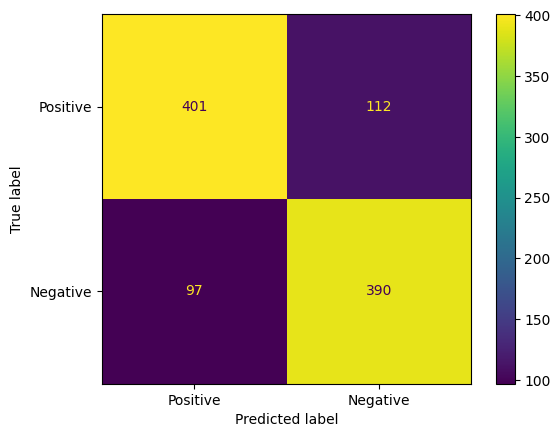

Accuracy: 0.79
Precision: 0.81
Recall: 0.78
F1 Score 0.79

Decisions Tree

Scores:  [0.735 0.75  0.785 0.78  0.72 ]

Mean : 0.75

Standard deviation: 0.03


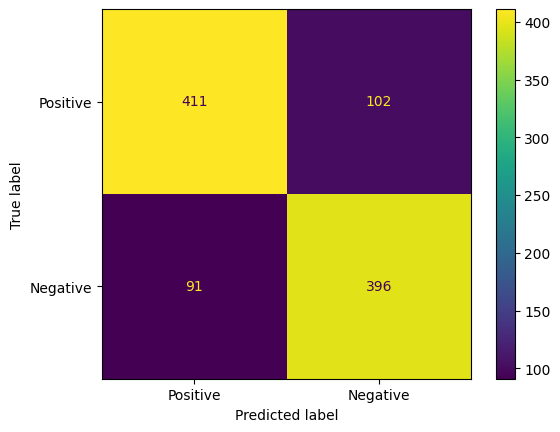

Accuracy: 0.81
Precision: 0.82
Recall: 0.80
F1 Score 0.81

Logistic Regression

Scores:  [0.705 0.665 0.67  0.725 0.68 ]

Mean : 0.69

Standard deviation: 0.02


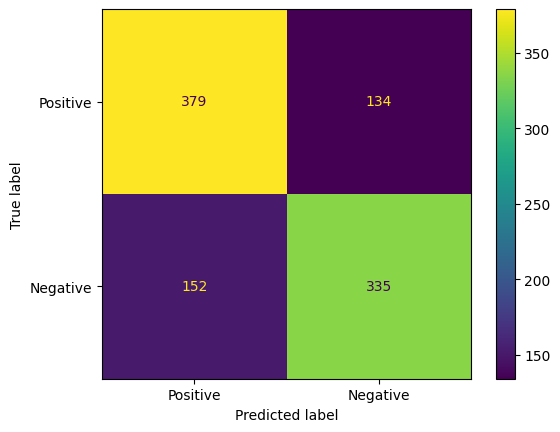

Accuracy: 0.71
Precision: 0.71
Recall: 0.74
F1 Score 0.73

Random Forest Classifier

Scores:  [0.835 0.8   0.85  0.805 0.825]

Mean : 0.82

Standard deviation: 0.02


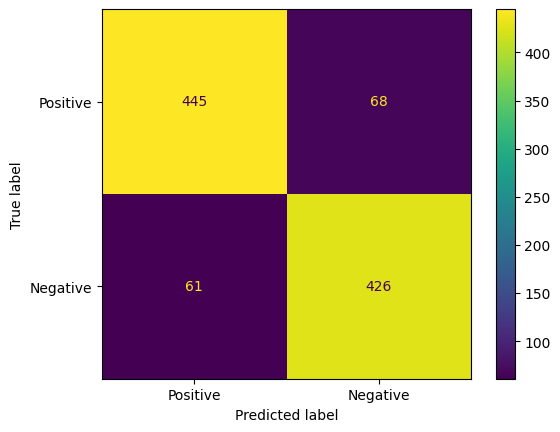

Accuracy: 0.87
Precision: 0.88
Recall: 0.87
F1 Score 0.87


In [ ]:
# Python code
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#KNN Scores Cross Validation

knn_scores = cross_val_score(knn, X_test, y_test, cv=5)
print('\nK-Nearest Neighbours')
print('\nScores: ', knn_scores)
print(f"\nMean : {knn_scores.mean():.2f}")
print(f"\nStandard deviation: {knn_scores.std():.2f}")

knn_preds = knn.predict(X_test)
knn_cm = confusion_matrix(y_test, knn_preds, labels=[1,0])

knn_disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=["Positive", "Negative"])
knn_disp.plot()
plt.show()

print(f"Accuracy: {accuracy_score(y_test, knn_preds):.2f}")
print(f"Precision: {precision_score(y_test, knn_preds):.2f}")
print(f"Recall: {recall_score(y_test, knn_preds):.2f}")
print(f"F1 Score {f1_score(y_test, knn_preds):.2f}")

#CLF Scores Cross Validation

clf_scores = cross_val_score(clf, X_test, y_test, cv=5)
print('\nDecisions Tree')
print('\nScores: ', clf_scores)
print(f"\nMean : {clf_scores.mean():.2f}")
print(f"\nStandard deviation: {clf_scores.std():.2f}")

clf_preds = clf.predict(X_test)
clf_cm = confusion_matrix(y_test, clf_preds, labels=[1,0])

clf_disp = ConfusionMatrixDisplay(confusion_matrix=clf_cm, display_labels=["Positive", "Negative"])
clf_disp.plot()
plt.show()

print(f"Accuracy: {accuracy_score(y_test, clf_preds):.2f}")
print(f"Precision: {precision_score(y_test, clf_preds):.2f}")
print(f"Recall: {recall_score(y_test, clf_preds):.2f}")
print(f"F1 Score {f1_score(y_test, clf_preds):.2f}")

#LogReg Cross Validation

logreg_scores = cross_val_score(logreg, X_test, y_test, cv=5)
print('\nLogistic Regression')
print('\nScores: ', logreg_scores)
print(f"\nMean : {logreg_scores.mean():.2f}")
print(f"\nStandard deviation: {logreg_scores.std():.2f}")

logreg_preds = logreg.predict(X_test)
logreg_cm = confusion_matrix(y_test, logreg_preds, labels=[1,0])

logreg_disp = ConfusionMatrixDisplay(confusion_matrix=logreg_cm, display_labels=["Positive", "Negative"])
logreg_disp.plot()
plt.show()

print(f"Accuracy: {accuracy_score(y_test, logreg_preds):.2f}")
print(f"Precision: {precision_score(y_test, logreg_preds):.2f}")
print(f"Recall: {recall_score(y_test, logreg_preds):.2f}")
print(f"F1 Score {f1_score(y_test, logreg_preds):.2f}")

#RF Scores Cross Validation

rf_scores = cross_val_score(rf, X_test, y_test, cv=5)
print('\nRandom Forest Classifier')
print('\nScores: ', rf_scores)
print(f"\nMean : {rf_scores.mean():.2f}")
print(f"\nStandard deviation: {rf_scores.std():.2f}")

rf_preds = rf.predict(X_test)
rf_cm = confusion_matrix(y_test, rf_preds, labels=[1,0])

rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["Positive", "Negative"])
rf_disp.plot()
plt.show()

print(f"Accuracy: {accuracy_score(y_test, rf_preds):.2f}")
print(f"Precision: {precision_score(y_test, rf_preds):.2f}")
print(f"Recall: {recall_score(y_test, rf_preds):.2f}")
print(f"F1 Score {f1_score(y_test, rf_preds):.2f}")



### Hyperparameter Optimization

(9) **Exploration and Performance Evaluation:**

- Investigate the impact of varying hyperparameter values on the performance of each model.

- For each model, ensure to vary at least the following hyperparameters:

    - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html):`n_neighbors` and `weights`.

    - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html):`criterion` and `max_depth`.
  
    - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html):`penalty`, `max_iter`, and `tol`.

    - [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html):`n_estimators`, `max_depth`.

- Employ a grid search strategy or utilize scikit-learn's built-in methods to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

- Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics. Report both the mean and standard deviation.

- Display the results in a tabular or graphical format (e.g., line charts, bar charts) to effectively demonstrate the influence of hyperparameter variations on model performance.

- Specify the default values for each hyperparameter tested.

Default Values

KNN: n_neighbours: 5. weights: uniform

Decision Tree: criterion: gini. max_depth: none

LogReg: penalty: l2. tol: 0.0001. Solvers: lbfgs. max_iter: 100.

RF: n_estimators: 100. max_depth: none.

- Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

For KNN model, the configuration that I have found to be the best is 24 N-Neighbors and weights being distance. I ended up testing up to n-neighbors being 75, and 24 still produced the best results.

For the Decision tree model,  I tested max_depth up to 24, and found that the optimal solution is 11 max_depth, and that entropy worked the best of the criterions.

For Logistic Regression, I test all options for tol, penalty, max_iter and solver, and the optimal hyper-parameters are max_iter=100, penalty=l2, solver=lbfgs and tol=0.001

For the Random Forest model, the optimal hyper-parameter values I found are max_depth=14/15 and n_estimators=100/150. I test between a range of 1 to 25 from max_depth, but have changed the code to reduce the time to run.

Some of my findings:

-It seems that generally, a good max_depth for this set of data is between 11 and 14, as is shown by the Decision tree and random forest models

-Going into the this testing, I expected that the more iterations of logreg I did, the better results the model would return. In actuality, the model actual perfomred better on a relatively low max_iterations
as well as a relatively high tolerance. I would hypothesize that this is caused by either multicollinearity or by the data being relatively non-linear.

-It seems that the models that look at clumping of points that are the same/similar are the most successful, compared to the models that are more linear.

As for the best overall model for this situation and for the hyper-parameter tuning and testing that I have done, the Random Forest model is the optimal choice for this situation, though K-Nearest Neighbors is not very far behind in terms of performance.  For the rest of this assignment, I shall use the Random Forest Model.





K-Nearest Neighbours Best Params
{'n_neighbors': 24, 'weights': 'distance'} 0.84375

Scores:  [0.8425  0.83125 0.88125 0.83    0.83375]

Mean : 0.84

Standard deviation: 0.02


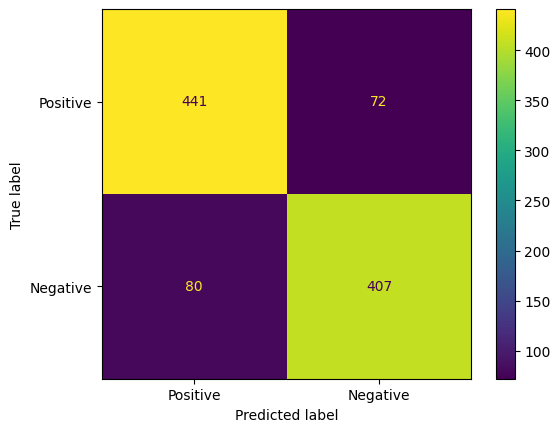

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       487
           1       0.85      0.86      0.85       513

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


CLF Best Params
{'criterion': 'log_loss', 'max_depth': 11} 0.818

Scores:  [0.81   0.83   0.8375 0.7975 0.8175]

Mean : 0.82

Standard deviation: 0.01


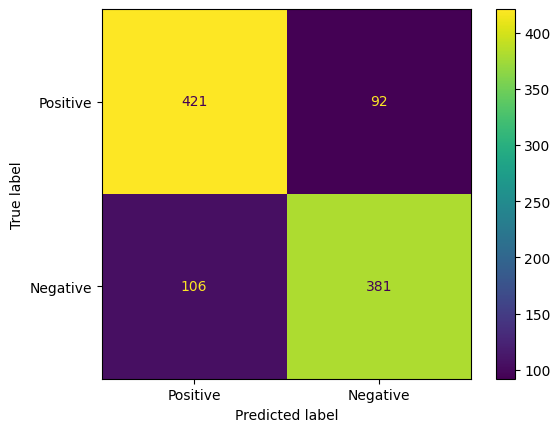

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       487
           1       0.80      0.82      0.81       513

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000


Logistic Regression Best Params


c:\Users\djbly\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\djbly\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\djbly\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\djbly\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\djbly\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

In [ ]:
# Python code
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

print('\nK-Nearest Neighbours Best Params')
knn_params_grid = [{
        'n_neighbors': range(1, 25),
        'weights': ["uniform", "distance"]    
}]

knn_grid_search = GridSearchCV(knn, knn_params_grid, cv=5)
knn_grid_search.fit(X_train, y_train)   
print(knn_grid_search.best_params_, knn_grid_search.best_score_)
best_neigh= knn_grid_search.best_params_.get('n_neighbors')
best_weights = knn_grid_search.best_params_.get('weights')

#KNN Best Params cross val and Confusion matrix
knn_best_params = KNeighborsClassifier(n_neighbors=best_neigh, metric='euclidean', weights=best_weights)
knn_best_params.fit(X_train, y_train)

knn_best_params_scores = cross_val_score(knn_best_params, X_train, y_train, cv=5)
print('\nScores: ', knn_best_params_scores)
print(f"\nMean : {knn_best_params_scores.mean():.2f}")
print(f"\nStandard deviation: {knn_best_params_scores.std():.2f}")

knn_best_params_preds = knn_best_params.predict(X_test)
knn_best_params_cm = confusion_matrix(y_test, knn_best_params_preds, labels=[1,0])

knn_best_params_disp = ConfusionMatrixDisplay(confusion_matrix=knn_best_params_cm, display_labels=["Positive", "Negative"])
knn_best_params_disp.plot()
plt.show()
print(classification_report(y_test, knn_best_params_preds))


print('\nCLF Best Params')
clf_param_grid = [
  {'max_depth': range(1, 12),
   'criterion': ["gini", "entropy", "log_loss"]}
]

clf_grid_search = GridSearchCV(clf, clf_param_grid, cv=5)

clf_grid_search.fit(X_train, y_train)

print(clf_grid_search.best_params_, clf_grid_search.best_score_)

best_depth = clf_grid_search.best_params_.get('max_depth')
best_crit = clf_grid_search.best_params_.get('criterion')

#CLF Best Params cross val and Confusion matrix
clf_best_params = tree.DecisionTreeClassifier(max_depth=best_depth, criterion=best_crit)
clf_best_params.fit(X_train, y_train)

clf_best_params_scores = cross_val_score(clf_best_params, X_train, y_train, cv=5)
print('\nScores: ', clf_best_params_scores)
print(f"\nMean : {clf_best_params_scores.mean():.2f}")
print(f"\nStandard deviation: {clf_best_params_scores.std():.2f}")

clf_best_params_preds = clf_best_params.predict(X_test)
clf_best_params_cm = confusion_matrix(y_test, clf_best_params_preds, labels=[1,0])

clf_best_params_disp = ConfusionMatrixDisplay(confusion_matrix=clf_best_params_cm, display_labels=["Positive", "Negative"])
clf_best_params_disp.plot()
plt.show()
print(classification_report(y_test, clf_best_params_preds))


print('\nLogistic Regression Best Params')
logreg_param_grid = [
  {'penalty': ['l1','l2', None],
   'max_iter' : [100, 200, 400, 800, 1600, 3200, 6400, 12800],
   'solver' : ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga'],
   'tol' : [0.01, 0.001, 0.0001, 0.00001, 0.000001]}
]

logreg_grid_search = GridSearchCV(logreg, logreg_param_grid, cv=5)

logreg_grid_search.fit(X_train, y_train)

print(logreg_grid_search.best_params_, logreg_grid_search.best_score_)

best_penalty = logreg_grid_search.best_params_.get('penalty')
best_max_iter = logreg_grid_search.best_params_.get('max_iter')
best_tol = logreg_grid_search.best_params_.get('tol')
best_solver = logreg_grid_search.best_params_.get('solver')

#logreg Best Params cross val and Confusion matrix
logreg_best_params = LogisticRegression(penalty=best_penalty, max_iter=best_max_iter, tol=best_tol, solver=best_solver)
logreg_best_params.fit(X_train, y_train)

logreg_best_params_scores = cross_val_score(logreg_best_params, X_train, y_train, cv=5)
print('\nScores: ', logreg_best_params_scores)
print(f"\nMean : {logreg_best_params_scores.mean():.2f}")
print(f"\nStandard deviation: {logreg_best_params_scores.std():.2f}")

logreg_best_params_preds = logreg_best_params.predict(X_test)
logreg_best_params_cm = confusion_matrix(y_test, logreg_best_params_preds, labels=[1,0])

logreg_best_params_disp = ConfusionMatrixDisplay(confusion_matrix=logreg_best_params_cm, display_labels=["Positive", "Negative"])
logreg_best_params_disp.plot()
plt.show()
print(classification_report(y_test, logreg_best_params_preds))




print('\nRandom Forest Best Params')

rf_param_grid = [
  {
    'n_estimators': [50, 75, 100, 150, 200, 250],
    'max_depth': range(13,16)
  }
]

rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5)

rf_grid_search.fit(X_train, y_train)

print(rf_grid_search.best_params_, rf_grid_search.best_score_)

best_n_estimators = rf_grid_search.best_params_.get('n_estimators')
best_rf_depth = rf_grid_search.best_params_.get('max_depth')


#Random Forest Best Params cross val and Confusion matrix
rf_best_params = RandomForestClassifier( max_depth=best_rf_depth, n_estimators=best_n_estimators)
rf_best_params.fit(X_train, y_train)

rf_best_params_scores = cross_val_score(rf_best_params, X_train, y_train, cv=5)
print('\nScores: ', rf_best_params_scores)
print(f"\nMean : {rf_best_params_scores.mean():.2f}")
print(f"\nStandard deviation: {rf_best_params_scores.std():.2f}")

rf_best_params_preds = rf_best_params.predict(X_test)
rf_best_params_cm = confusion_matrix(y_test, rf_best_params_preds, labels=[1,0])

rf_best_params_disp = ConfusionMatrixDisplay(confusion_matrix=rf_best_params_cm, display_labels=["Positive", "Negative"])
rf_best_params_disp.plot()
plt.show()
print(classification_report(y_test, rf_best_params_preds))

totalData = {
    'Classifer': ['N-Neighbbours', 'Decision Tree', 'Logistic Regression', 'Random Forest'],
    'Precision': [precision_score(y_test, knn_best_params_preds), precision_score(y_test, clf_best_params_preds), precision_score(y_test, logreg_best_params_preds), precision_score(y_test, rf_best_params_preds)],
    'Recall': [recall_score(y_test, knn_best_params_preds), recall_score(y_test, clf_best_params_preds), recall_score(y_test, logreg_best_params_preds), recall_score(y_test, rf_best_params_preds)],
    'F1 Score': [f1_score(y_test, knn_best_params_preds), f1_score(y_test, clf_best_params_preds), f1_score(y_test, logreg_best_params_preds), f1_score(y_test, rf_best_params_preds)],
    'Mean': [knn_best_params_scores.mean(), clf_best_params_scores.mean(), logreg_best_params_scores.mean(), rf_best_params_scores.mean()],
    'Standard Deviation': [knn_best_params_scores.std(), clf_best_params_scores.std(), logreg_best_params_scores.std(), rf_best_params_scores.std()]
}

resultsData = pd.DataFrame(totalData)
print(resultsData)

### Analysis of Results

(10) **Model Comparison**:

- Compare the results obtained from each model.

See Above sections

- Discuss observed differences in model performance, providing potential explanations. Consider aspects such as model complexity, data imbalance, overfitting, and the impact of parameter tuning on overall results.

As I mentioned earlier, for the logistic regression model, I believe that the issues that are causing the reduced performance is a lack of linear relations and multicollinearity. 

For the Decision Tree Classifier Model, again I believe that the lack of linear-relations has a part in the model performing worse than KNN and RF as this data set is complex with non-linear relations betweenfeaatures. Furthermore, I also believe that this data has an inate problem with overfitting, as the RF model specifically reduces overfiiting and variance, and performs much better than this model.

As mentioned above, I believe a large part of the KNN model performing so well is its ability to work with non-linear relationships and complex data in general. 

As for why I believe that the Random Forest performs the best on this dataset, I metioned earlier that reducing overfittig is a large part of why this model works so well, I also believe that the models ability to reduce variance and its robustness to outliers is another attribute that lends to this models success.

- Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

As stated earlier, I believe that the best model to use or this situation based on the results is the Random Forest Model, and the KNN model is another very very good option that is only slightly worse than the random forest model. Looking at the results of our tests and analysis, the Random Forest model definitively outperforms the other three models in every aspect, with the only exception being that the logistic regression model 
has a better standard deviation

- Train the recommended model(s) using the optimal parameter values identified from the parameter optimization step. Subsequently, apply the trained model to the test data. Document your observations comprehensively. Specifically, evaluate whether the results derived from cross-validation are consistent with those obtained from the test set.


Scores:  [0.84  0.81  0.85  0.84  0.825]

Mean : 0.83

Standard deviation: 0.01


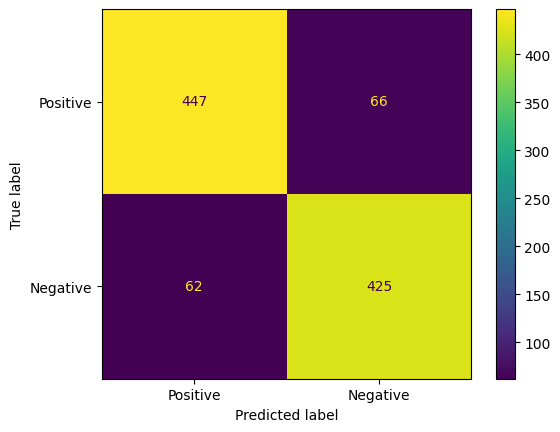

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       487
           1       0.88      0.87      0.87       513

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



In [ ]:
# Python code
rf_best_params_scores_test = cross_val_score(rf_best_params, X_test, y_test, cv=5)
print('\nScores: ', rf_best_params_scores_test)
print(f"\nMean : {rf_best_params_scores_test.mean():.2f}")
print(f"\nStandard deviation: {rf_best_params_scores_test.std():.2f}")

rf_best_params_preds_test = rf_best_params.predict(X_test)
rf_best_params_test_cm = confusion_matrix(y_test, rf_best_params_preds_test, labels=[1,0])

rf_best_params_disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_best_params_test_cm, display_labels=["Positive", "Negative"])
rf_best_params_disp_test.plot()
plt.show()
print(classification_report(y_test, rf_best_params_preds_test))

### Handling Missing Data

(11) **Evaluate how missing values affect model performance:**

- Read the CSV file with missing data (`alien_pet_health-realism-clean-missing.csv`).

- Present a brief analysis of missing data within the dataset by reporting both the count and percentage of missing values foreach column as well as for the dataset as a whole. Additionally, provide a breakdown of the number and proportion of rowscategorized by the absence of missing data, and those containing one, two, or more missing values.

- Apply a simple imputation strategy (for instance, median for numeric, and most_frequent for categoricals).

- Standardize and normalize the numerical features, and encode the categorical data using the data pre-processing methodspreviously described.

- Utilize cross-validation to assess the effectiveness of the data imputation strategy, given that the optimal combination oflearning algorithms and hyperparameters has already been determined.

- Discuss observed differences in performance.

There is very minimal difference in performance using the missing vs non-missing dataset. One key difference that I did notice is an uptake of Negative Postives, approximately a jump of 15-20% (jumped from around 60-65 in complete, and 75-80 in missing). This is quite interesting, as the other three quadrants changes were relatively uniform. This means that the system is cateforizing more pets as dead when they are alive when the data is missing information.

My hypothesis is that this is caused due to an inbalance between number of positive health outcomes compared to negative health outcomes (recall). Since we are taking the average of all features for the missing values (50/50), it makes sense that it would shift the inclination to have a more "even" distribution of positive and negative outcomes, when the resulting outcome is more aligned with (55/45), which would account of more pets being classified as a negative outcome and the lower overall recall score.

(5000, 8)
   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  \
0                -3.5           c2             2.0           0.0   
1                10.5           c1             2.0           0.0   
2                 9.6           c2             5.0           0.0   
3                -4.0           c1             4.0           0.0   
4                 0.3           c4             5.0           1.0   

   health_outcome  
0               1  
1               0  
2               0  
3               1  
4               1  
thermoreg_reading        231
enzyme_activity_index    108
dual_lobe_si

C:\Users\djbly\AppData\Local\Temp\ipykernel_11164\2470238353.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_missing['thermoreg_reading'].fillna(df_missing['thermoreg_reading'].mean(), inplace=True)
C:\Users\djbly\AppData\Local\Temp\ipykernel_11164\2470238353.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set


Scores:  [0.84875 0.835   0.8625  0.81875 0.8475 ]

Mean : 0.84

Standard deviation: 0.01


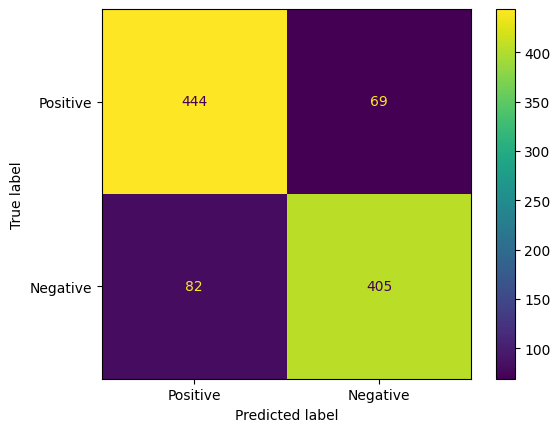

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       487
           1       0.84      0.87      0.85       513

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



In [ ]:
# Python code
data_missing = pd.read_csv("https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean-missing.csv")
print(data_missing.shape)
print(data_missing.head())
df_missing = pd.DataFrame(data_missing)

#Analysis of missing data
missing_count_per_column = data_missing.isnull().sum()
total_missing_values = missing_count_per_column.sum()
print(missing_count_per_column)

missing_count_per_row = data_missing.isnull().sum(axis=1)
print('Are there any missing in health_outcome?' ,data_missing['health_outcome'].isnull().any())
print('Number of missing values per Rows')
print(missing_count_per_row.value_counts())

df_missing['thermoreg_reading'].fillna(df_missing['thermoreg_reading'].mean(), inplace=True)
df_missing['enzyme_activity_index'].fillna(df_missing['enzyme_activity_index'].mean(), inplace=True)
df_missing['dual_lobe_signal'].fillna(df_missing['dual_lobe_signal'].mean(), inplace=True)
df_missing['stress_variability'].fillna(df_missing['stress_variability'].mean(), inplace=True)

df_missing['habitat_zone'].fillna(df_missing['habitat_zone'].mode()[0], inplace=True)
df_missing['fasting_flag'].fillna(df_missing['fasting_flag'].mode()[0], inplace=True)
df_missing['activity_score'].fillna(df_missing['activity_score'].mode()[0], inplace=True)

missing_count_per_row = data_missing.isnull().sum(axis=1)
print('Number of missing values per Rows after imputation')
print(missing_count_per_row.value_counts())
missing_count_per_column = data_missing.isnull().sum()
print('Number of missing values per col after imputation')
print(missing_count_per_column)

##Categorical Encoding
habitats = data_missing[['habitat_zone']]

onehot_encoder = OneHotEncoder()

onehot_encoder.fit(data_missing[['habitat_zone']])
values_encoded = onehot_encoder.transform(data_missing[['habitat_zone']]).toarray()
#for i in range(5): print(values_encoded)

encoded_df = pd.DataFrame(values_encoded, columns=onehot_encoder.get_feature_names_out(['habitat_zone']), index=data_missing.index)
data_missing.drop('habitat_zone', axis= 1, inplace=True)
data_missing_encoded = pd.concat([data_missing, encoded_df], axis=1)

ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(data_missing[['fasting_flag']])
values_encoded = ordinal_encoder.transform(data_missing[['fasting_flag']])

encoded_df = pd.concat([encoded_df, pd.DataFrame(values_encoded, columns=ordinal_encoder.get_feature_names_out(['fasting_flag']), index=data_missing.index)], axis=1)
data_missing.drop('fasting_flag', axis= 1, inplace=True)
data_missing_encoded = pd.concat([data_missing, encoded_df], axis=1)


ordinal_encoder.fit(data_missing[['activity_score']])
values_encoded = ordinal_encoder.transform(data_missing[['activity_score']])

encoded_df = pd.concat([encoded_df, pd.DataFrame(values_encoded, columns=ordinal_encoder.get_feature_names_out(['activity_score']), index=data_missing.index)], axis=1)
data_missing.drop('activity_score', axis= 1, inplace=True)
data_missing_encoded = pd.concat([data_missing, encoded_df], axis=1)

y_data_missing = data_missing_encoded['health_outcome']
X_data_missing = data_missing_encoded.drop('health_outcome', axis=1)

X_data_missing_train, X_data_missing_test, y_data_missing_train, y_data_missing_test = train_test_split(X_data_missing, y_data_missing, test_size=0.2, random_state=3)

# print(y_train.head())
# print(y_test.head())
# print(X_train.head())
# print(X_test.head())

# print(X_test.head())
norm_scaler = MinMaxScaler()

duallobe_normalized =  norm_scaler.fit_transform(X_data_missing_train[['dual_lobe_signal']])
duallobe_norm_df = pd.DataFrame(duallobe_normalized, columns=norm_scaler.get_feature_names_out(['dual_lobe_signal']), index=X_data_missing_train.index)

X_data_missing_train.drop('dual_lobe_signal', axis=1, inplace=True)
X_data_missing_train = pd.concat([X_data_missing_train, duallobe_norm_df], axis=1)

thermoreg_scaler = StandardScaler()
X_data_missing_train_treg_scaled = thermoreg_scaler.fit_transform(X_data_missing_train[['thermoreg_reading']])
X_data_missing_train_treg_scaled_df = pd.DataFrame(X_data_missing_train_treg_scaled,columns=thermoreg_scaler.get_feature_names_out(['thermoreg_reading']), index=X_data_missing_train.index)

enzyme_scaler = StandardScaler()
X_data_missing_train_enzyme_scaled = enzyme_scaler.fit_transform(X_data_missing_train[['enzyme_activity_index']])
X_data_missing_train_enzyme_scaled_df = pd.DataFrame(X_data_missing_train_enzyme_scaled,columns=enzyme_scaler.get_feature_names_out(['enzyme_activity_index']), index=X_data_missing_train.index)

stress_scaler = StandardScaler()
X_data_missing_train_stress_scaled = stress_scaler.fit_transform(X_data_missing_train[['stress_variability']])
X_data_missing_train_stress_scaled_df = pd.DataFrame(X_data_missing_train_stress_scaled,columns=stress_scaler.get_feature_names_out(['stress_variability']), index=X_data_missing_train.index)

X_data_missing_train.drop('thermoreg_reading', axis=1, inplace=True)
X_data_missing_train.drop('enzyme_activity_index', axis=1, inplace=True)
X_data_missing_train.drop('stress_variability', axis=1, inplace=True)

X_data_missing_train= pd.concat([X_data_missing_train, X_data_missing_train_treg_scaled_df, X_data_missing_train_enzyme_scaled_df, X_data_missing_train_stress_scaled_df],axis=1)

#Test from here

X_data_missing_test_normalized = norm_scaler.transform(X_data_missing_test[['dual_lobe_signal']])
X_data_missing_test_norm_df = pd.DataFrame(X_data_missing_test_normalized, columns=norm_scaler.get_feature_names_out(['dual_lobe_signal']), index=X_data_missing_test.index)
X_data_missing_test.drop('dual_lobe_signal', axis=1, inplace=True)
X_data_missing_test = pd.concat([X_data_missing_test, X_data_missing_test_norm_df], axis=1)

X_data_missing_test_treg_scaled = thermoreg_scaler.transform(X_data_missing_test[['thermoreg_reading']])
X_data_missing_test_treg_scaled_df = pd.DataFrame(X_data_missing_test_treg_scaled,columns=thermoreg_scaler.get_feature_names_out(['thermoreg_reading']), index=X_data_missing_test.index)

X_data_missing_test_enzyme_scaled = enzyme_scaler.transform(X_data_missing_test[['enzyme_activity_index']])
X_data_missing_test_enzyme_scaled_df = pd.DataFrame(X_data_missing_test_enzyme_scaled,columns=enzyme_scaler.get_feature_names_out(['enzyme_activity_index']), index=X_data_missing_test.index)

X_data_missing_test_stress_scaled = stress_scaler.transform(X_data_missing_test[['stress_variability']])
X_data_missing_test_stress_scaled_df = pd.DataFrame(X_data_missing_test_stress_scaled,columns=stress_scaler.get_feature_names_out(['stress_variability']), index=X_data_missing_test.index)

X_data_missing_test.drop('thermoreg_reading', axis=1, inplace=True)
X_data_missing_test.drop('enzyme_activity_index', axis=1, inplace=True)
X_data_missing_test.drop('stress_variability', axis=1, inplace=True)

X_data_missing_test= pd.concat([X_data_missing_test, X_data_missing_test_treg_scaled_df, X_data_missing_test_enzyme_scaled_df, X_data_missing_test_stress_scaled_df],axis=1)

# print(X_data_missing_test.head())

rf_mv_bp = RandomForestClassifier( max_depth=best_rf_depth, n_estimators=best_n_estimators)
rf_mv_bp.fit(X_data_missing_train, y_data_missing_train)

rf_mv_bp_scores = cross_val_score(rf_mv_bp, X_data_missing_train, y_data_missing_train, cv=5)
print('\nScores: ', rf_mv_bp_scores)
print(f"\nMean : {rf_mv_bp_scores.mean():.2f}")
print(f"\nStandard deviation: {rf_mv_bp_scores.std():.2f}")

rf_mv_bp_preds = rf_mv_bp.predict(X_data_missing_test)
rf_mv_bp_cm = confusion_matrix(y_data_missing_test, rf_mv_bp_preds, labels=[1,0])

rf_mv_bp_disp = ConfusionMatrixDisplay(confusion_matrix=rf_mv_bp_cm, display_labels=["Positive", "Negative"])
rf_mv_bp_disp.plot()
plt.show()
print(classification_report(y_data_missing_test, rf_mv_bp_preds))



### Model Explainability (Optional)

Explainability in machine learning refers to the ability to understand and interpret the decisions made by a model. SHAP (SHapley Additive exPlanations) values provide a unified measure to explain the contribution of each feature to the model's prediction, offering insights into how and why a model makes specific predictions, thus enhancing transparency and trust in complex models.

This question is optional. You may choose to address it if you wish to explore the topic or if you are seeking to earn bonus points.

(12) **Feature Importance:**

- With the hyperparameters already optimized, calculate the [SHAP](https://shap.readthedocs.io/en/latest/index.html) (SHapley Additive exPlanations) values to evaluate feature importance for the K-Nearest Neighbors (KNN), Decision Trees, and Logistic Regression models. For each model, produce a summary plot that identifies and emphasizes the five most influential features used during the classification stage.

In [ ]:
# Python code

# References
https://scikit-learn.org/
https://www.w3schools.com/python
https://www.geeksforgeeks.org/
https://stackoverflow.com/

# Resources


If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation 
ChatGPT-5
https://chatgpt.com/c/68f555a2-0ffc-8327-b149-f02e9a838ab5